In [1]:
DATASET = "multimodal"
INSTANCE = 3
SEED = 2421
DATASET_KWARGS = {"n": 300, "ell_range": [0.5, 1.0]}

LENGTHSCALE_INIT = 1.0
LENGTHSCALE_MIN = 1.0e-3
LENGTHSCALE_MAX = 1.0e3

NUM_PARTICLES = 32
ALPHA = 1.0
STEP_SIZE = 1.0e-4

SIGMA_INIT = 0.2
SIGMA_MIN = 0.1
SIGMA_MAX = 1.0
SIGMA_LR = 0.1
KERNEL_LR = 0.01

VAL_FRACTION = 0.25
ADAPT_TARGET = None
NUM_ADAPT_STEPS = 20000
WARMUP_STEPS = 1000
SIGMA_ADAPT_STEPS = 600
KERNEL_ADAPT_STEPS = 300

NUM_SAMPLE_STEPS = 3000
BURN_FRACTION = 0.9
THIN = 50

NUM_FUNCTION_DRAWS = 100

In [2]:
from non_parametric_pro.data.synthetic.block_outliers import BLOCK_OUTLIERS_KWARGS, make_block_outlier_instance, plot_block_outlier_case
from non_parametric_pro.data.synthetic.heteroskedastic import HETEROSKEDASTIC_KWARGS, make_heteroskedastic_instance, plot_heteroskedastic_case
from non_parametric_pro.data.synthetic.multimodal import MULTIMODAL_KWARGS, make_multimodal_instance, plot_multimodal_case
from non_parametric_pro.data.synthetic.well_specified import WELL_SPECIFIED_KWARGS, make_well_specified_instance, plot_well_specified_case

DATASET_SOURCES = {
    "block_outliers": (make_block_outlier_instance, plot_block_outlier_case, BLOCK_OUTLIERS_KWARGS),
    "heteroskedastic": (make_heteroskedastic_instance, plot_heteroskedastic_case, HETEROSKEDASTIC_KWARGS),
    "multimodal": (make_multimodal_instance, plot_multimodal_case, MULTIMODAL_KWARGS),
    "well_specified": (make_well_specified_instance, plot_well_specified_case, WELL_SPECIFIED_KWARGS),
}

In [3]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px
import numpy as np

from non_parametric_pro import ula
from non_parametric_pro.ula import parametric_ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.util import (
    cholesky_basis,
    nlpd_gp,
    nlpd_pro,
    posterior_function_draws,
    prediction_basis,
    predictive_moments,
    run_inference_algorithm_with_burn_in,
    train_val_split,
)
from non_parametric_pro.inducing import PointInducingBasis
from non_parametric_pro.parameter_adaptation import parameter_adaptation

jax.config.update("jax_enable_x64", True)

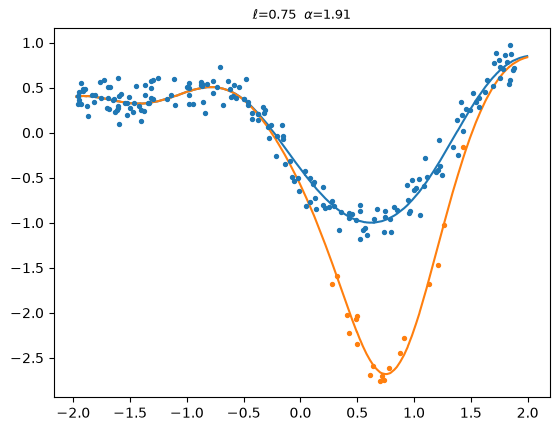

In [4]:
key = jr.PRNGKey(SEED)
instance_keys = jr.split(key, num=20)
instance_key = instance_keys[INSTANCE]

make_instance, plot_case, dataset_kwarg_names = DATASET_SOURCES[DATASET]
dataset_kwargs = {k: v for k, v in DATASET_KWARGS.items() if k in dataset_kwarg_names}
example = make_instance(instance_key, **dataset_kwargs)

x_train, y_train = example.x_train, example.y_train
x_test, y_test = example.x_test, example.y_test

idx = np.argsort(x_test.squeeze())
x_test = x_test[idx]
y_test = y_test[idx]

fig, ax = plt.subplots()
plot_case(ax, example)

In [5]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
exact_gp_kernel = gpx.kernels.RBF(lengthscale=LENGTHSCALE_INIT)

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=exact_gp_kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    verbose=False,
)

gp_latent_train_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_train_dist = gp_posterior.likelihood(gp_latent_train_dist)

gp_predictive_train_mean = gp_predictive_train_dist.mean
gp_predictive_train_std = jnp.sqrt(gp_predictive_train_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

In [6]:
kernel = gpx.kernels.RBF(
    lengthscale=gpx.parameters.SigmoidBounded(LENGTHSCALE_INIT, low=LENGTHSCALE_MIN, high=LENGTHSCALE_MAX)
)
basis_full = cholesky_basis(kernel, x_train)
basis_dim = basis_full.shape[1]
row_selectable_basis = PointInducingBasis(z=x_train)

key, split_key, pos_key, adapt_key = jr.split(key, 4)
split = train_val_split(split_key, x_train, y_train, val_fraction=VAL_FRACTION)

fold_params = ProParameters(
    y=split.y_train,
    step_size=STEP_SIZE,
    sigma=gpx.parameters.SigmoidBounded(SIGMA_INIT, low=SIGMA_MIN, high=SIGMA_MAX),
    alpha=ALPHA,
)
initial_position = jr.normal(pos_key, (basis_dim, NUM_PARTICLES))

adaptation = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    fold_params,
    x_train=split.x_train,
    initial_kernel=kernel,
    warmup_steps=WARMUP_STEPS,
    sigma_adapt_steps=SIGMA_ADAPT_STEPS,
    kernel_adapt_steps=KERNEL_ADAPT_STEPS,
    objective_fn=pro_logdensity_fn,
    inducing_basis=row_selectable_basis,
    x_val=split.x_val,
    y_val=split.y_val,
    adapt_target=ADAPT_TARGET,
    sigma_optimizer=ox.adam(SIGMA_LR),
    kernel_optimizer=ox.adam(KERNEL_LR),
    progress_bar=True,
)
adaptation_results, adaptation_info = adaptation.run(adapt_key, initial_position, num_steps=NUM_ADAPT_STEPS)
adapted_sigma = px.unwrap(adaptation_results.parameters.sigma)
print("Adapted sigma:", adapted_sigma)

Running parameter adaptation


<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

Adapted sigma: 0.1389573240658356


In [7]:
if KERNEL_ADAPT_STEPS > 0:
    adapted_kernel = px.unwrap(jax.tree.map(lambda x: x[-1], adaptation_info.kernel))
    basis_full = cholesky_basis(adapted_kernel, x_train)
else:
    adapted_kernel = kernel

print("lengthscale:", px.unwrap(adapted_kernel.lengthscale))
print("variance:", px.unwrap(adapted_kernel.variance))

pro_params = ProParameters(
    y=y_train,
    basis=basis_full,
    step_size=STEP_SIZE,
    sigma=adaptation_results.parameters.sigma,
    alpha=ALPHA,
    residual_std=None,
)
algorithm = parametric_ula(pro_logdensity_fn, pro_params)
key, sample_key = jr.split(key)
_, (states, _) = run_inference_algorithm_with_burn_in(
    rng_key=sample_key,
    inference_algorithm=algorithm,
    num_steps=NUM_SAMPLE_STEPS,
    burn_ratio=BURN_FRACTION,
    initial_position=adaptation_results.state.position,
    progress_bar=True,
)
particles = states.position[::THIN]

lengthscale: 0.7021919327048856
variance: 0.714634788808381


<div><progress max="2700" value="2700"></progress> 100.00% [2700/2700 00:00&lt;?]</div>

<div><progress max="300" value="300"></progress> 100.00% [300/300 00:00&lt;?]</div>

In [8]:
test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_train, pro_params
)
print("PRO Train NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params))

test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

print("PRO Test NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))
print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO Train NLPD: -0.40136046291109895
PRO Test NLPD: -0.21723073489745798
GP Train NLPD: 0.38396681008721917
GP Test NLPD: 0.33168017173133024


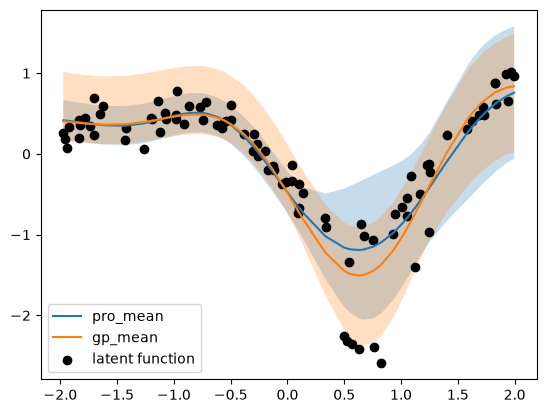

In [9]:
mean, std = predictive_moments(test_basis, particles, noise_std=adapted_sigma)

x_plot = x_test.squeeze()

plt.plot(x_plot, mean, label="pro_mean")
plt.plot(x_plot, gp_predictive_mean, label="gp_mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.fill_between(x_plot, gp_predictive_mean - 1.64 * std, gp_predictive_mean + 1.64 * gp_predictive_std, alpha=0.25)
plt.scatter(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function")
plt.legend()
plt.show()

In [10]:
test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=NUM_FUNCTION_DRAWS,
    jitter=pro_params.jitter,
)

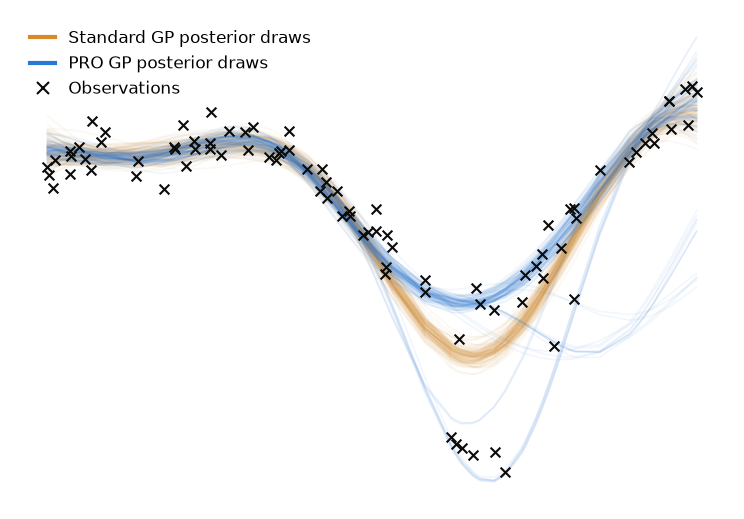

In [11]:
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

pro_color = "#2a78d6"
gp_color = "#d68a2a"
obs_color = "#0b0b0b"
num_draws = draws.shape[1]

key, gp_draw_key = jr.split(key)
gp_draws = np.asarray(gp_latent_dist.sample(gp_draw_key, sample_shape=(num_draws,))).T  # (N_test, num_draws)

order = np.argsort(x_test.squeeze())
x_sorted = x_test.squeeze()[order]
y_sorted = y_test.squeeze()[order]
pro_draws_sorted = np.asarray(draws)[order]
gp_draws_sorted = gp_draws[order]

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=150)

ax.plot(x_sorted, gp_draws_sorted, color=gp_color, alpha=0.06, linewidth=0.8, rasterized=True)
ax.plot(x_sorted, pro_draws_sorted, color=pro_color, alpha=0.06, linewidth=0.8, rasterized=True)
ax.scatter(x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0, zorder=5)

legend_handles = [
    Line2D([0], [0], color=gp_color, linewidth=2.0, label="Standard GP posterior draws"),
    Line2D([0], [0], color=pro_color, linewidth=2.0, label="PRO GP posterior draws"),
    Line2D([0], [0], color=obs_color, marker="x", linestyle="None", markersize=6, label="Observations"),
]
ax.legend(handles=legend_handles, loc="best", handlelength=1.5)

ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
plt.show()